## 1.0 Set up File

1.1 Import packages

In [1]:
import pandas as pd
from PIL import Image
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf  # For tf.data
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.applications import EfficientNetB0
import scipy

In [2]:
tf.keras.backend.clear_session()

1.2 Define Model Parameters

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 16

1.3 Read in Data

In [4]:
# Load dataframe
df = pd.read_csv("fossils_augmented.csv")

# Shuffle the dataframe for tensorflow training
df = df.sample(frac=1, random_state=10).reset_index(drop=True)

In [5]:
print(f"Total images: {len(df)}")
print(df["period"].value_counts())

Total images: 3611
period
Silurian Period         1024
Ordovician Period        337
Permian Period           250
Carboniferous Period     250
Jurassic Period          250
Cretaceous Period        250
Triassic Period          250
Cambrian Period          250
Precambrian Eon          250
Devonian Period          250
Cenozoic Era             250
Name: count, dtype: int64


1.4 Train/Test Split Data

In [6]:
# Split so no augmented images are in validation/test sets
train_df = df[df["augmented"] == True]
orig_df  = df[df["augmented"] == False]

# 80/20 split on originals only
val_df   = orig_df.sample(frac=0.2, random_state=42)
train_orig_df = orig_df.drop(val_df.index)

# Combine original training rows with augmented rows
train_df = pd.concat([train_orig_df, train_df], ignore_index=True).sample(frac=1, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 3144 | Val: 467


1.5 Run DataGenerators on Images

In [7]:
train_datagen = ImageDataGenerator()
val_datagen   = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="local_path",
    y_col="period",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical", # one-hot encoding period labels
    shuffle=True,
    seed=1
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="local_path",
    y_col="period",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical", # one-hot encoding period labels
    shuffle=False
)

Found 3144 validated image filenames belonging to 11 classes.
Found 467 validated image filenames belonging to 11 classes.


1.6 Save Class Names and Batches

In [8]:
# Save class names for prediction later
import json
class_names = list(train_gen.class_indices.keys())
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"\nClasses: {class_names}")
print(f"Training batches:   {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")


Classes: ['Cambrian Period', 'Carboniferous Period', 'Cenozoic Era', 'Cretaceous Period', 'Devonian Period', 'Jurassic Period', 'Ordovician Period', 'Permian Period', 'Precambrian Eon', 'Silurian Period', 'Triassic Period']
Training batches:   197
Validation batches: 30


## 2.0 Create Model

2.1 Define EfficientNetB0 Model

In [9]:
# Number of classes for final layer
NUM_CLASSES = len(class_names)

# build model
base = EfficientNetB0(
    weights="imagenet",      # use pretrained weights
    include_top=False,       # remove ImageNet classification head
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False       # freeze base for phase 1

# add custom classification head
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])


# HEAD ONLY TRAINING is for the dense, final output layers that are added on the frozen base
# BASE layers are those that extract features from images and are pretrained on ImageNet
# compile model for training
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3), # higher learning rate for head-only training
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 11)                2

2.2 Head Only Training

In [10]:
# Train the head layers first with the base frozen to get a good starting point for the final layers
hist1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10, # number of forward/backward passes on the whole dataset, can be adjusted based on convergence
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10
197/197 [==============================] - 84s 288ms/step - loss: 1.8182 - accuracy: 0.4539 - val_loss: 1.2972 - val_accuracy: 0.5503
Epoch 2/10
197/197 [==============================] - 9s 46ms/step - loss: 1.0683 - accuracy: 0.6482 - val_loss: 1.1190 - val_accuracy: 0.6060
Epoch 3/10
197/197 [==============================] - 7s 36ms/step - loss: 0.8163 - accuracy: 0.7166 - val_loss: 1.1654 - val_accuracy: 0.5910
Epoch 4/10
197/197 [==============================] - 7s 35ms/step - loss: 0.6689 - accuracy: 0.7675 - val_loss: 1.1108 - val_accuracy: 0.6381
Epoch 5/10
197/197 [==============================] - 8s 42ms/step - loss: 0.5793 - accuracy: 0.7987 - val_loss: 1.0054 - val_accuracy: 0.6552
Epoch 6/10
197/197 [==============================] - 9s 44ms/step - loss: 0.5050 - accuracy: 0.8257 - val_loss: 1.0882 - val_accuracy: 0.6531
Epoch 7/10
197/197 [==============================] - 8s 40ms/step - loss: 0.4417 - accuracy: 0.8499 - val_loss: 1.0583 - val_accuracy: 0.66

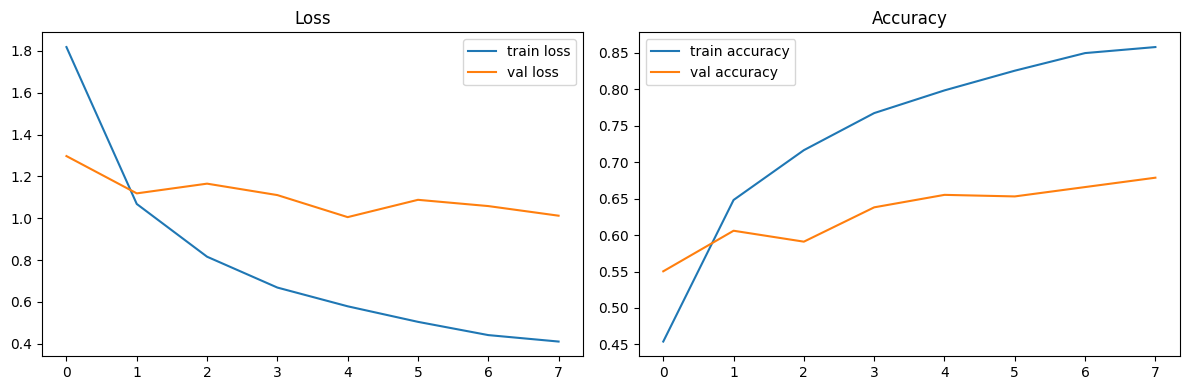

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist1.history["loss"], label="train loss")
axes[0].plot(hist1.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist1.history["accuracy"], label="train accuracy")
axes[1].plot(hist1.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

2.3 Unfreeze Base, Whole Model Training

In [13]:
# UNFREEZE BASE for fine-tuning with a much lower learning rate to avoid destroying pretrained weights
base.trainable = True

# Recompile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune the whole model with a lower learning rate and more epochs, using callbacks to prevent overfitting
hist2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30, # number of forward/backward passes on the whole dataset, can be adjusted based on convergence
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.2)
    ]
)

# Save just the weights
model.save_weights("fossil_model_weights.h5")

# Save the class names too
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

Epoch 1/30


197/197 [==============================] - 55s 176ms/step - loss: 0.3130 - accuracy: 0.8909 - val_loss: 0.9983 - val_accuracy: 0.6788 - lr: 1.0000e-05
Epoch 2/30
197/197 [==============================] - 32s 162ms/step - loss: 0.2766 - accuracy: 0.9087 - val_loss: 0.9875 - val_accuracy: 0.6681 - lr: 1.0000e-05
Epoch 3/30
197/197 [==============================] - 29s 146ms/step - loss: 0.3003 - accuracy: 0.9030 - val_loss: 0.9945 - val_accuracy: 0.6767 - lr: 1.0000e-05
Epoch 4/30
197/197 [==============================] - 28s 141ms/step - loss: 0.2713 - accuracy: 0.9071 - val_loss: 0.9881 - val_accuracy: 0.6831 - lr: 1.0000e-05
Epoch 5/30
197/197 [==============================] - 30s 154ms/step - loss: 0.2623 - accuracy: 0.9167 - val_loss: 0.9807 - val_accuracy: 0.6788 - lr: 1.0000e-05
Epoch 6/30
197/197 [==============================] - 31s 155ms/step - loss: 0.2488 - accuracy: 0.9208 - val_loss: 0.9796 - val_accuracy: 0.6852 - lr: 1.0000e-05
Epoch 7/30
197/197 [===================

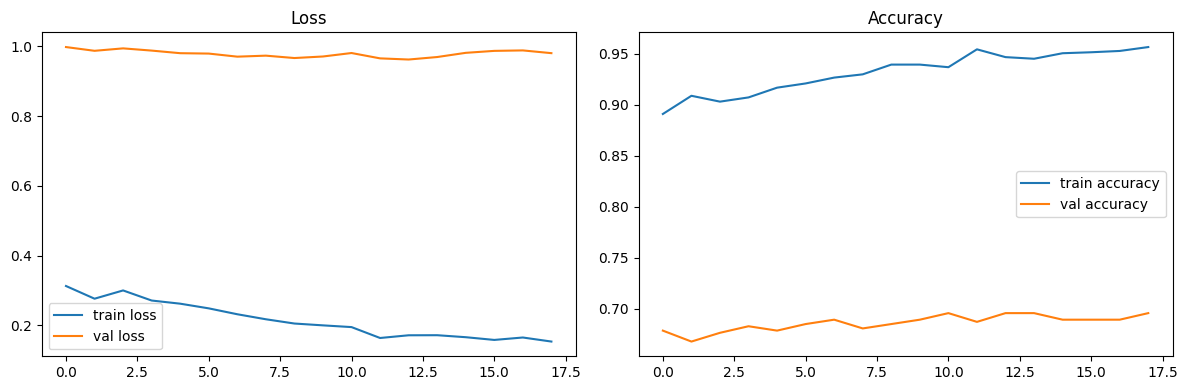

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist2.history["loss"], label="train loss")
axes[0].plot(hist2.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist2.history["accuracy"], label="train accuracy")
axes[1].plot(hist2.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()